# Decision Tree

In [90]:
# Importing required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',200)
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.tree import plot_tree

## 1. Data Preparation

In [4]:
# Loading dataset
df=pd.read_excel('C:/Data Science/Assignments_Files/Decision Tree/heart_disease.xlsx',sheet_name="Heart_disease")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [28]:
# Creating copy of dataset for backup
df_copy=df.copy()

In [8]:
# Checking Size of the dataset
df.shape

(908, 13)

In [10]:
# Checking column names and there datatypes
df.dtypes

age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs            bool
restecg      object
thalch        int64
exang        object
oldpeak     float64
slope        object
thal         object
num           int64
dtype: object

## 2. Exploratory Data Analysis (EDA)

In [14]:
# Understanding Statistical Info
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [16]:
# Structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [20]:
# Checking for duplicates
df[df.duplicated()]

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
765,58,Male,non-anginal,150,219,False,st-t abnormality,118,True,0.0,downsloping,normal,2


In [22]:
# Dropping duplicates
df.drop_duplicates(inplace=True)

In [26]:
# Checking for Null values
df.isna().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [30]:
# Replacing null values with median
df.oldpeak.fillna(df.oldpeak.median(),inplace=True)

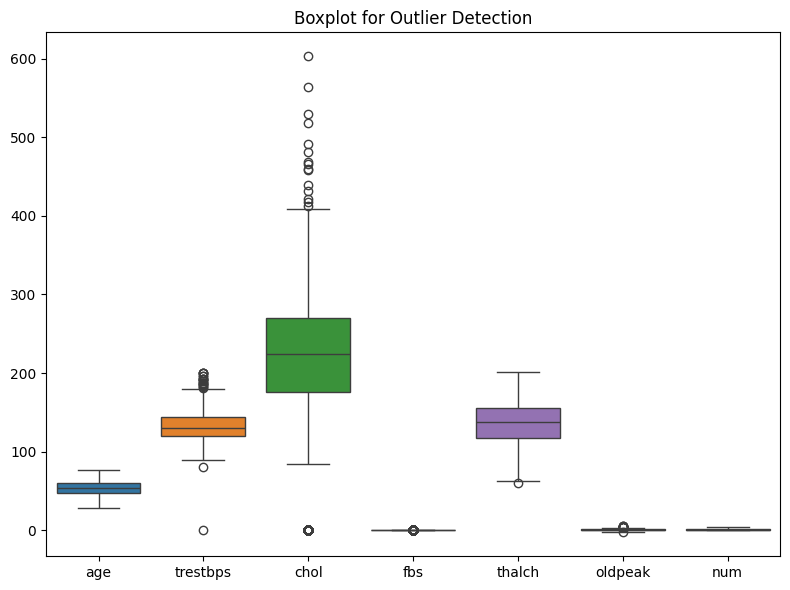

In [38]:
# Checking for outliers using boxplot
plt.figure(figsize=(8,6))
sns.boxplot(df)
plt.title("Boxplot for Outlier Detection")
plt.tight_layout()
plt.show()

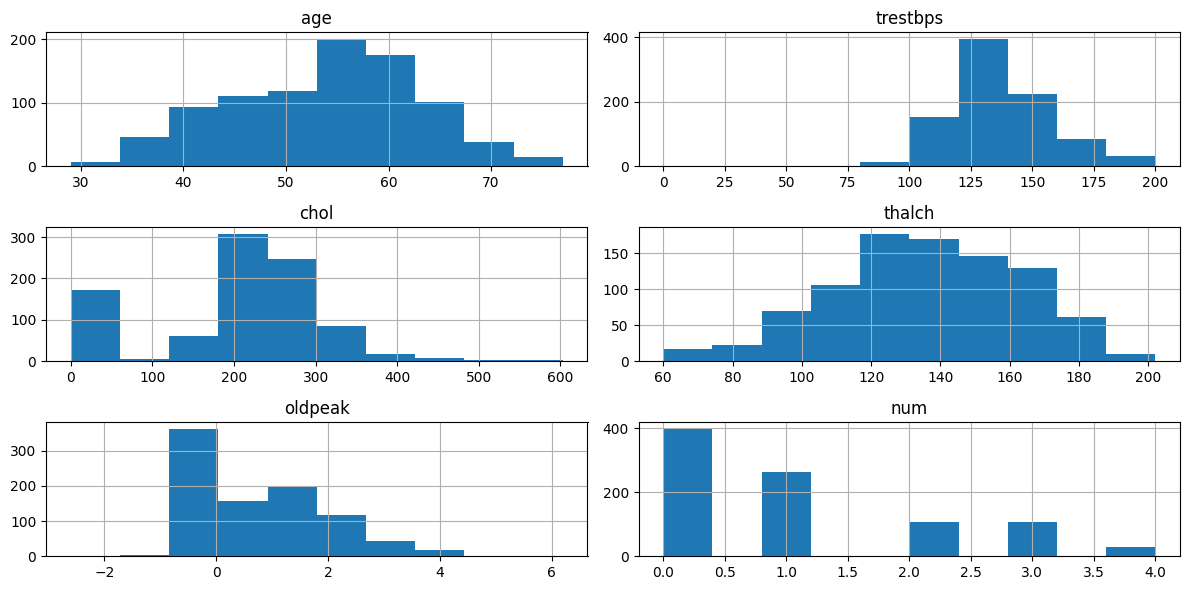

In [42]:
# Feature Distribution using Histogram
df.hist(figsize=(12,6))
plt.tight_layout()
plt.show()

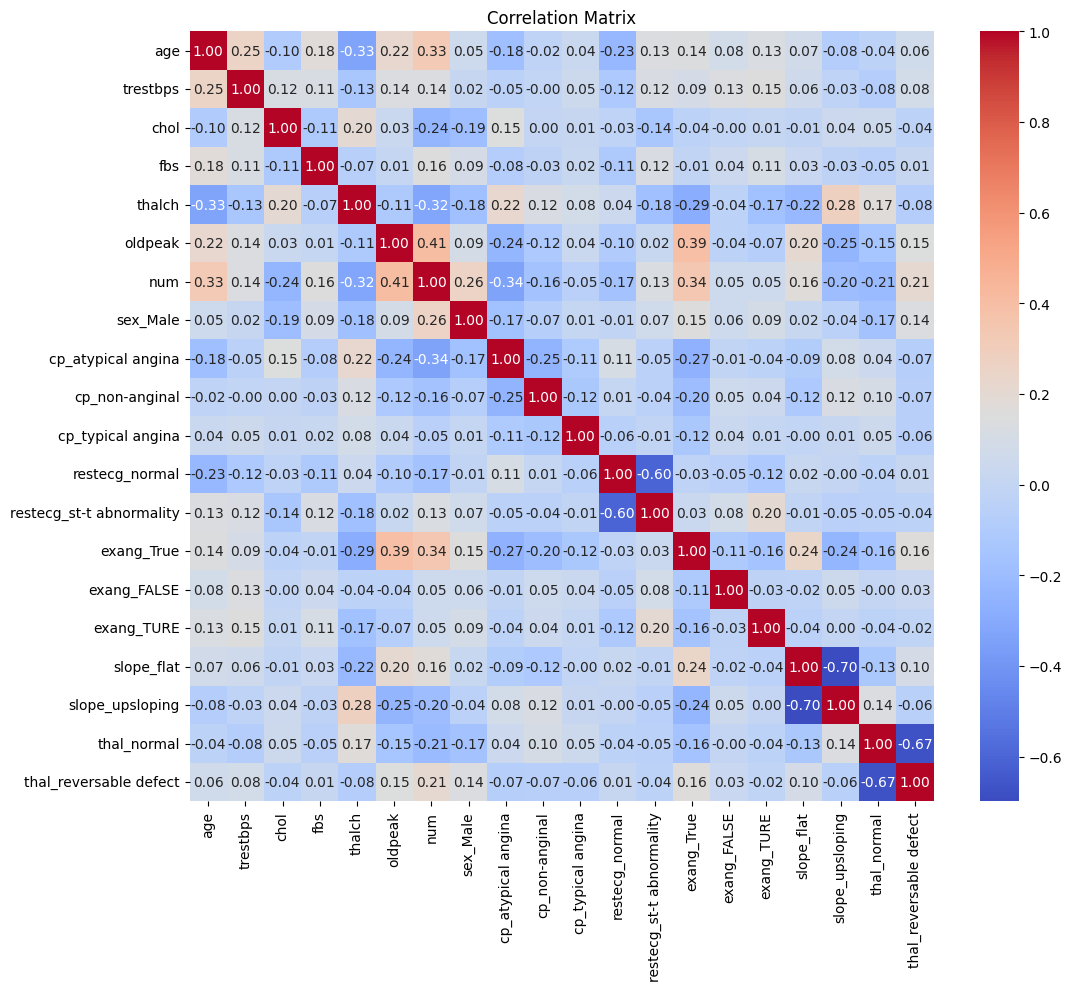

In [44]:
# Correlation Matrix
df_encoded = pd.get_dummies(df, drop_first=True)

plt.figure(figsize=(12,10))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

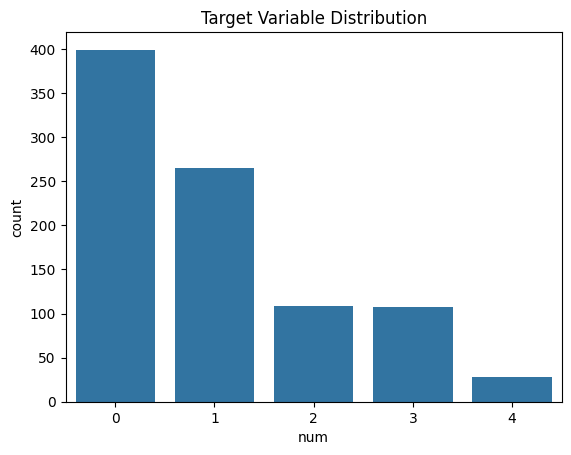

In [46]:
# Target Variable Distribution
sns.countplot(x='num', data=df)
plt.title("Target Variable Distribution")
plt.show()

## 3. Feature Engineering

In [51]:
# Feature Scaling on df_encoded
scaler = StandardScaler()
X = df_encoded.drop('num', axis=1)
y = df_encoded['num']

X_scaled = scaler.fit_transform(X)

In [53]:
# Feature & Target Split
X = df_encoded.drop('num', axis=1)
y = df_encoded['num']

In [57]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 4. Decision Tree Classification

In [62]:
# Training Decision Tree Model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [64]:
# Predictions
y_pred = model.predict(X_test)

In [70]:
# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.4945054945054945


In [74]:
# Precision, Recall, F1-score
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.67      0.70        89
           1       0.44      0.47      0.45        47
           2       0.22      0.30      0.26        20
           3       0.09      0.12      0.10        17
           4       0.00      0.00      0.00         9

    accuracy                           0.49       182
   macro avg       0.30      0.31      0.30       182
weighted avg       0.50      0.49      0.50       182



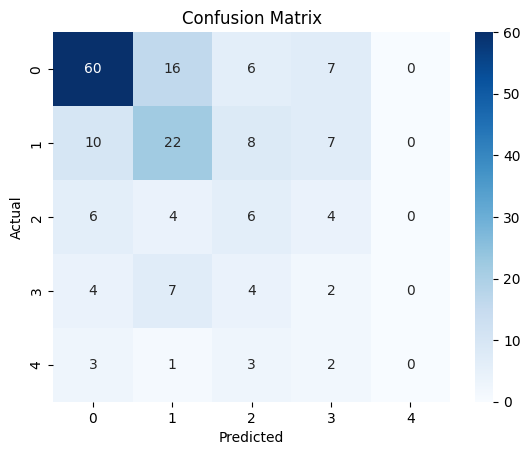

In [78]:
# Confusion matrix of predictions
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [84]:
# ROC-AUC Score
y_prob = model.predict_proba(X_test)

roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.5854328482371147


## 6. Model Evaluation and Analysis


In [87]:
# Confusion Matrix Analysis
print(cm)

[[60 16  6  7  0]
 [10 22  8  7  0]
 [ 6  4  6  4  0]
 [ 4  7  4  2  0]
 [ 3  1  3  2  0]]


The confusion matrix shows that the model performs well for class 0, with the highest number of correct predictions (60). However, the performance decreases for other classes, especially class 3 and class 4.

The model struggles to correctly classify higher classes, as seen from the low diagonal values. In particular, class 4 has zero correct predictions, indicating that the model is unable to learn patterns for this class.

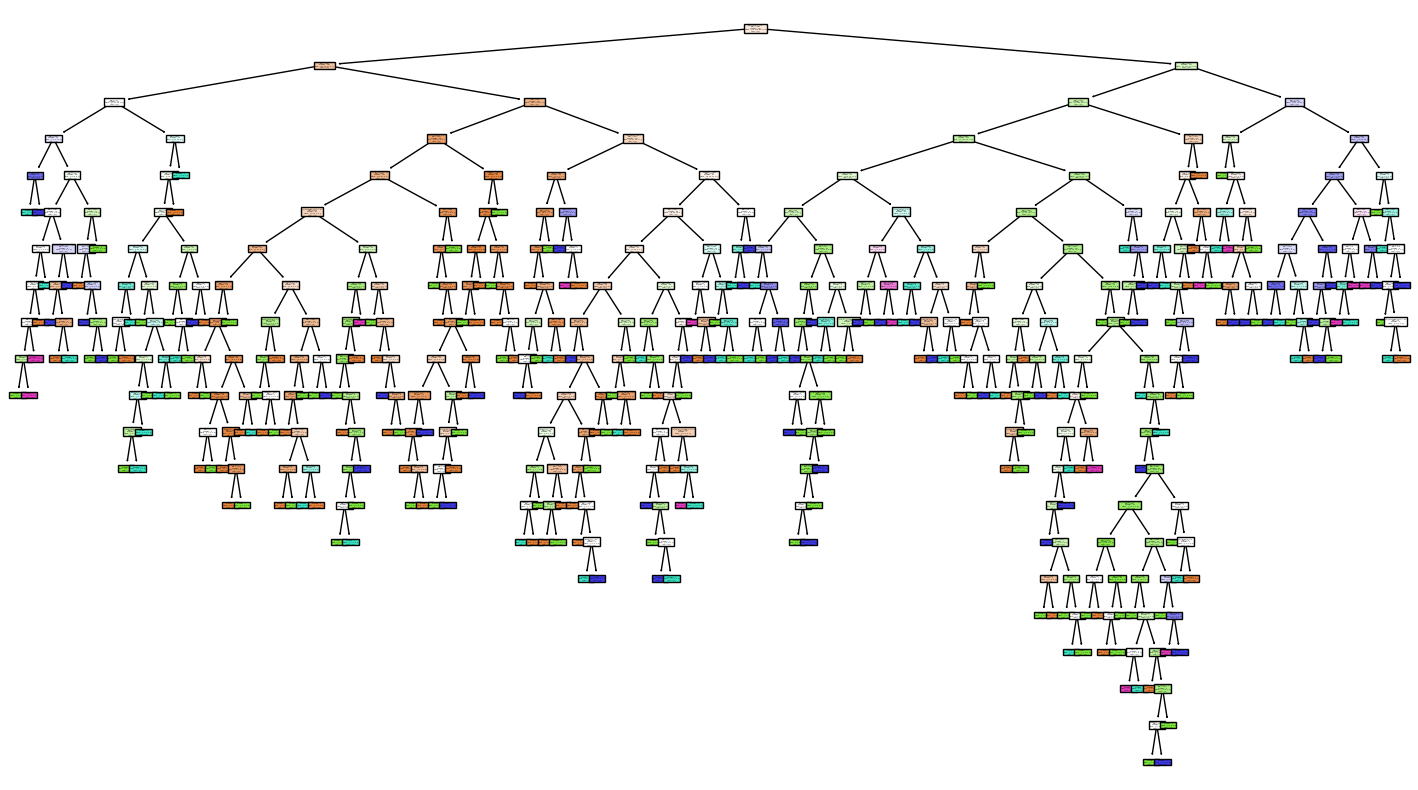

In [92]:
# Visualizing Decision Tree
plt.figure(figsize=(18,10))
plot_tree(model, filled=True, feature_names=X.columns, class_names=True)
plt.show()

In [94]:
# Feature Importance 
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)
print(importance.head(10))

chol                      0.163234
age                       0.139445
oldpeak                   0.133370
thalch                    0.132244
trestbps                  0.127234
exang_True                0.090699
slope_flat                0.028715
thal_normal               0.026564
restecg_normal            0.026347
thal_reversable defect    0.024850
dtype: float64


Feature importance analysis shows which variables contribute most to the model's predictions. Features such as (top features like thalach, cp, oldpeak, etc.) were found to have the highest importance, indicating their strong influence on heart disease prediction.

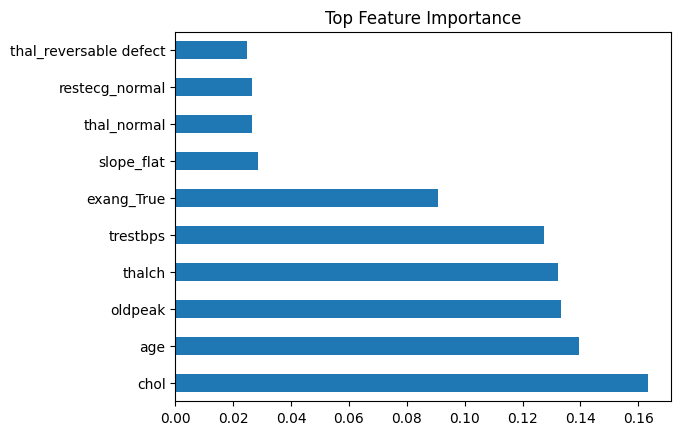

In [97]:
importance.head(10).plot(kind='barh')
plt.title("Top Feature Importance")
plt.show()

# Interview Questions & Answers

## 1. Decision Tree Hyperparameters

- **max_depth** → Controls tree depth (small = less overfitting, large = overfitting)
- **min_samples_split** → Minimum samples to split a node (higher = simpler tree)
- **min_samples_leaf** → Minimum samples in leaf (prevents very small leaves)
- **criterion** → Split quality (gini or entropy)
- **max_features** → Number of features used (reduces overfitting)

**Summary:**  
These parameters control how complex the tree is and help avoid overfitting.

---

## 2. Label Encoding vs One-Hot Encoding

### Label Encoding
- Converts categories into numbers  
- Example: Male = 0, Female = 1  
- Problem: Model may assume order

### One-Hot Encoding
- Creates separate columns for each category  
- Example:  
  Male → [1,0]  
  Female → [0,1]  
- No order assumption

**Summary:**  
- Label Encoding → Simple but may create false order  
- One-Hot Encoding → Safer and commonly used